# Comparing with Marli's lab meeting plots

medRxiv preprint: doi.org/10.64898/2026.01.27.26344979

Let's try to replicate the key plots from Marlis's analysis using Muscle Skeletal GTEx v11
SuSiE fine-mapped eQTLs × AlphaGenome raw scores for ClinGen HI and Background gene sets.

**Plots to try:**
- Slide 8: Global concordance (all variants) vs extreme AG scores (quantile > 0.99)
- Slide 10: Variant-level score summaries (rho ~ 0.02)
- Slides 11–14: CS-level aggregation improving rho to 0.21 → 0.44
- Slide 16: Spearman rho across PIP and quantile cutoffs

**Difference from Marlis:** She used CD4+ T cell eQTLs and ChromBPNet; we use Muscle Skeletal
GTEx v11 SuSiE and AlphaGenome raw_score (max across tracks per variant × gene window).

In [58]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import rankdata, pearsonr

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

def _resolve_project_root():
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            return candidate
    raise FileNotFoundError('config.py not found')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import GENE_PATHS, VARIANT_PATHS, SOURCE_PALETTE
from utils.plot_utils import save_plot

NOTEBOOK_NAME = '05_marlis_comparison'
SUSIE_PATH = PROJECT_ROOT / '09_3103_biweekly' / 'Muscle_Skeletal.v11.eQTLs.SuSiE_summary.parquet'
FIG_DIR = PROJECT_ROOT / '10_THESIS' / 'FIGURES_FOR_THESIS'
FIG_DIR.mkdir(parents=True, exist_ok=True)

COLOR_HI = SOURCE_PALETTE['clingen']
COLOR_BG = SOURCE_PALETTE['background']

def signed_rho(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = np.asarray(x)[mask], np.asarray(y)[mask]
    r, p = stats.spearmanr(x, y)
    ps = 'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
    return r, p, ps

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/markus/master-thesis-lappalainen/in-silico-vg-analysis


## 1. Loading suise

In [59]:
susie_raw = pl.read_parquet(SUSIE_PATH)
print('SuSiE columns:', sorted(susie_raw.columns))
print(f'SuSiE rows: {susie_raw.height:,}')
print(f'Rows with afc: {susie_raw.filter(pl.col("afc").is_not_null()).height:,}')

HAS_CS_ID = 'cs_id' in susie_raw.columns
HAS_SLOPE  = 'slope' in susie_raw.columns   # nominal slope
print(f'\ncs_id column: {HAS_CS_ID}')
print(f'slope column: {HAS_SLOPE}')
print('\nFirst 3 rows:')
print(susie_raw.head(3))

SuSiE columns: ['af', 'afc', 'afc_se', 'biotype', 'cs_id', 'cs_size', 'gene_name', 'phenotype_id', 'pip', 'variant_id']
SuSiE rows: 272,555
Rows with afc: 13,568

cs_id column: True
slope column: False

First 3 rows:
shape: (3, 10)
┌───────────────┬───────────┬─────────┬───────────────┬───┬───────┬─────────┬───────────┬──────────┐
│ phenotype_id  ┆ gene_name ┆ biotype ┆ variant_id    ┆ … ┆ cs_id ┆ cs_size ┆ afc       ┆ afc_se   │
│ ---           ┆ ---       ┆ ---     ┆ ---           ┆   ┆ ---   ┆ ---     ┆ ---       ┆ ---      │
│ str           ┆ str       ┆ str     ┆ str           ┆   ┆ i32   ┆ i64     ┆ f32       ┆ f32      │
╞═══════════════╪═══════════╪═════════╪═══════════════╪═══╪═══════╪═════════╪═══════════╪══════════╡
│ ENSG000003105 ┆ WASH7P    ┆ lncRNA  ┆ chr1_665098_G ┆ … ┆ 1     ┆ 2       ┆ null      ┆ null     │
│ 26.1          ┆           ┆         ┆ _A_b38        ┆   ┆       ┆         ┆           ┆          │
│ ENSG000003105 ┆ WASH7P    ┆ lncRNA  ┆ chr1_666028_G ┆ … ┆ 1

In [60]:
# Build normalised join key: chrom:pos:ref>alt
# SuSiE variant_id format: chr1_12345_A_T_b38
keep_cols = ['join_key', 'gene_id', 'pip', 'afc']
if HAS_CS_ID:
    keep_cols.append('cs_id')

susie_join = (
    susie_raw
    .filter(pl.col('afc').is_not_null())
    .with_columns(
        pl.col('phenotype_id').str.replace(r'\.\d+$', '').alias('gene_id'),
        (
            pl.col('variant_id').str.replace_all('_b38$', '')
            .str.splitn('_', 4)
            .struct.rename_fields(['chrom', 'pos', 'ref', 'alt'])
        ).alias('parts')
    )
    .unnest('parts')
    .with_columns(
        (pl.col('chrom') + ':' + pl.col('pos') + ':' +
         pl.col('ref') + '>' + pl.col('alt')).alias('join_key')
    )
    .select(keep_cols)
)

if HAS_CS_ID:
    print(f'Unique credible sets: {susie_join["cs_id"].n_unique():,}')
print(f'Unique genes in SuSiE: {susie_join["gene_id"].n_unique():,}')
print(f'Unique variant positions with afc: {susie_join["join_key"].n_unique():,}')

# Best-PIP entry per variant position (for variant-level analysis)
susie_best = (
    susie_join
    .sort('pip', descending=True)
    .group_by('join_key')
    .first()
)
print(f'\nSuSiE best-PIP per position: {susie_best.height:,} rows')

Unique credible sets: 7
Unique genes in SuSiE: 10,011
Unique variant positions with afc: 12,953

SuSiE best-PIP per position: 12,953 rows


## 2. Position-based join: all scored variants × SuSiE

Now joinig on variant position only (not gene_id), so any AlphaGenome-scored variant that appears in the SuSiE fine-mapping is captured regardless of which gene window it was scored in. Max |raw_score| is taken per variant position across all gene windows.

In [61]:
frames = []
for label, path in [('ClinGen HI', VARIANT_PATHS['clingen']),
                    ('Background',  VARIANT_PATHS['background'])]:
    ag = (
        pl.scan_parquet(path)
        .select(['variant_id', 'raw_score'])
        .collect()
        .with_columns(pl.col('raw_score').abs().alias('abs_score'))
        .sort('abs_score', descending=True)
        .group_by('variant_id')        # position-level dedup: keep max |raw_score|
        .first()
        .drop('abs_score')
        .rename({'variant_id': 'join_key'})
        .with_columns(pl.lit(label).alias('group'))
    )
    joined = ag.join(susie_best, on='join_key', how='inner')
    frames.append(joined)
    print(f'{label}: {ag.height:,} unique positions scored  →  {joined.height:,} matched to SuSiE')

df_matched = pl.concat(frames).to_pandas()
df_hi_m = df_matched[df_matched['group'] == 'ClinGen HI']
df_bg_m = df_matched[df_matched['group'] == 'Background']

print(f'\nTotal matched: {len(df_matched):,}  (HI: {len(df_hi_m):,}, BG: {len(df_bg_m):,})')
print('\nMatched data columns:', list(df_matched.columns))

ClinGen HI: 1,292,916 unique positions scored  →  51 matched to SuSiE
Background: 1,308,193 unique positions scored  →  162 matched to SuSiE

Total matched: 213  (HI: 51, BG: 162)

Matched data columns: ['join_key', 'raw_score', 'group', 'gene_id', 'pip', 'afc', 'cs_id']


In [62]:
# Quantile score = percentile rank of |raw_score| within all matched variants
#  Marlis's quantile_score slide 7)
abs_scores = df_matched['raw_score'].abs().values
df_matched['quantile_score'] = rankdata(abs_scores, method='average') / len(abs_scores)

df_hi_m = df_matched[df_matched['group'] == 'ClinGen HI']
df_bg_m = df_matched[df_matched['group'] == 'Background']

n_extreme = (df_matched['quantile_score'] > 0.99).sum()
print(f'quantile_score range: [{df_matched["quantile_score"].min():.3f}, {df_matched["quantile_score"].max():.3f}]')
print(f'N variants with quantile_score > 0.99: {n_extreme} ({100*n_extreme/len(df_matched):.1f}%)')

quantile_score range: [0.005, 1.000]
N variants with quantile_score > 0.99: 3 (1.4%)


## 3. Global concordance vs extreme scores  
Marli slide 8

**Coverage:** SuSiE Muscle Skeletal parquet has 12,953 variant positions with `afc`.
Our AlphaGenome-scored variants (ClinGen HI + Background gene windows) overlap only **213** of those  
(~1.6%) — because we scored regulatory windows around our specific gene sets, not genome-wide.  
The analyses below are honest about this limitation.

Left: all 213 matched variants — expect ρ ≈ 0 (Marlis had R²=0.002, N=186,311 from a genome-wide set)  
Right: variants with quantile_score > 0.99 — n=3, insufficient for any conclusion

All variants:     R²=0.0154,  ρ=0.019,  p = 0.784,  n=213
Quantile > 0.99:  R²=0.8412,  ρ=0.500,  p = 0.667,  n=3
[save_plot] Saved: 05_marlis_comparison_05_slide8_global_concordance_24042026_2234.pdf
[save_plot] Saved: 05_marlis_comparison_05_slide8_global_concordance_24042026_2234.svg


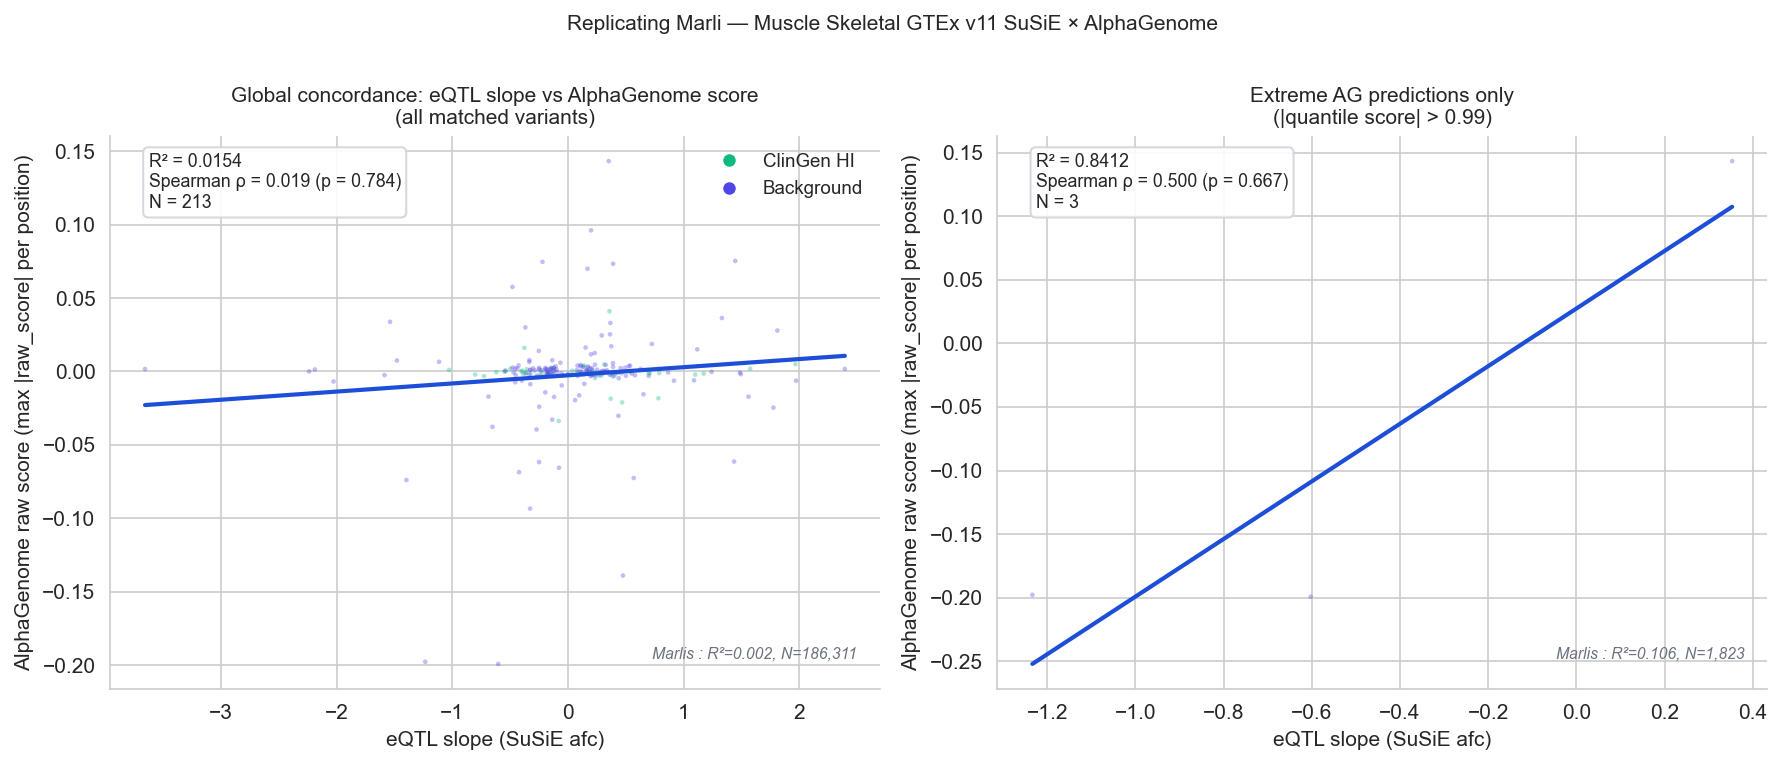

In [63]:
QUANTILE_THRESH = 0.99
df_extreme = df_matched[df_matched['quantile_score'] > QUANTILE_THRESH].copy()

r2 = {}
rho_stats = {}
for key, data in [('all', df_matched), ('extreme', df_extreme)]:
    x, y = data['afc'].values, data['raw_score'].values
    rp, _ = pearsonr(x, y)
    r2[key] = rp ** 2
    rho_stats[key] = signed_rho(x, y)

print(f'All variants:     R²={r2["all"]:.4f},  ρ={rho_stats["all"][0]:.3f},  {rho_stats["all"][2]},  n={len(df_matched):,}')
print(f'Quantile > 0.99:  R²={r2["extreme"]:.4f},  ρ={rho_stats["extreme"][0]:.3f},  {rho_stats["extreme"][2]},  n={len(df_extreme):,}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, key, title in [
    (axes[0], df_matched, 'all',
     'Global concordance: eQTL slope vs AlphaGenome score\n(all matched variants)'),
    (axes[1], df_extreme, 'extreme',
     f'Extreme AG predictions only\n(|quantile score| > {QUANTILE_THRESH})'),
]:
    hue = data['group'].map({'ClinGen HI': COLOR_HI, 'Background': COLOR_BG})
    ax.scatter(data['afc'], data['raw_score'],
               c=hue, s=5, alpha=0.35, edgecolors='none', zorder=2)
    sl, ic, *_ = stats.linregress(data['afc'], data['raw_score'])
    xr = np.linspace(data['afc'].min(), data['afc'].max(), 200)
    ax.plot(xr, sl*xr + ic, color='#1D4ED8', lw=2.0, zorder=3)
    ax.set_xlabel('eQTL slope (SuSiE afc)', fontsize=10)
    ax.set_ylabel('AlphaGenome raw score (max |raw_score| per position)', fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.text(0.05, 0.97,
            f'R² = {r2[key]:.4f}\nSpearman ρ = {rho_stats[key][0]:.3f} ({rho_stats[key][2]})\nN = {len(data):,}',
            transform=ax.transAxes, va='top', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#D1D5DB', alpha=0.9))
    # Marlis reference
    ref_r2 = 0.002 if key == 'all' else 0.106
    ref_n  = '186,311' if key == 'all' else '1,823'
    ax.text(0.97, 0.05,
            f'Marlis : R²={ref_r2}, N={ref_n}',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=7.5,
            color='#6B7280', style='italic')
    sns.despine(ax=ax)

# Manual legend
from matplotlib.lines import Line2D
leg = [Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_HI, markersize=7, label='ClinGen HI'),
       Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_BG, markersize=7, label='Background')]
axes[0].legend(handles=leg, frameon=False, fontsize=9)

fig.suptitle('Replicating Marli — Muscle Skeletal GTEx v11 SuSiE × AlphaGenome', fontsize=10, y=1.01)
fig.tight_layout()
save_plot(fig=fig, title='05_slide8_global_concordance', notebook=NOTEBOOK_NAME, outdir=FIG_DIR)
plt.show()

## 3b. slope + ALL variants, no SuSiE matching for density layer

Left panel— signed `raw_score` on **symlog** x-scale: shows the spike at x≈0\n(most variants have near-zero predicted effect) AND the tails where concordance lives.

Right panel — `|raw_score|` on **log₁₀** scale vs `|afc|`: shows absolute effect magnitude concordance.\n\nThe density strip is loaded directly from `VARIANT_PATHS` with position-level dedup (max |raw_score|\nper unique position across all gene windows). **No SuSiE matching required for that layer.**  \nThe OLS slope is from the SuSiE-matched subset — the reference relationship.

ClinGen HI: 1,292,916 unique positions
Background: 1,308,193 unique positions
[save_plot] Saved: 05_marlis_comparison_05_slope_all_variants_symlog_loglog_24042026_2238.pdf
[save_plot] Saved: 05_marlis_comparison_05_slope_all_variants_symlog_loglog_24042026_2238.svg


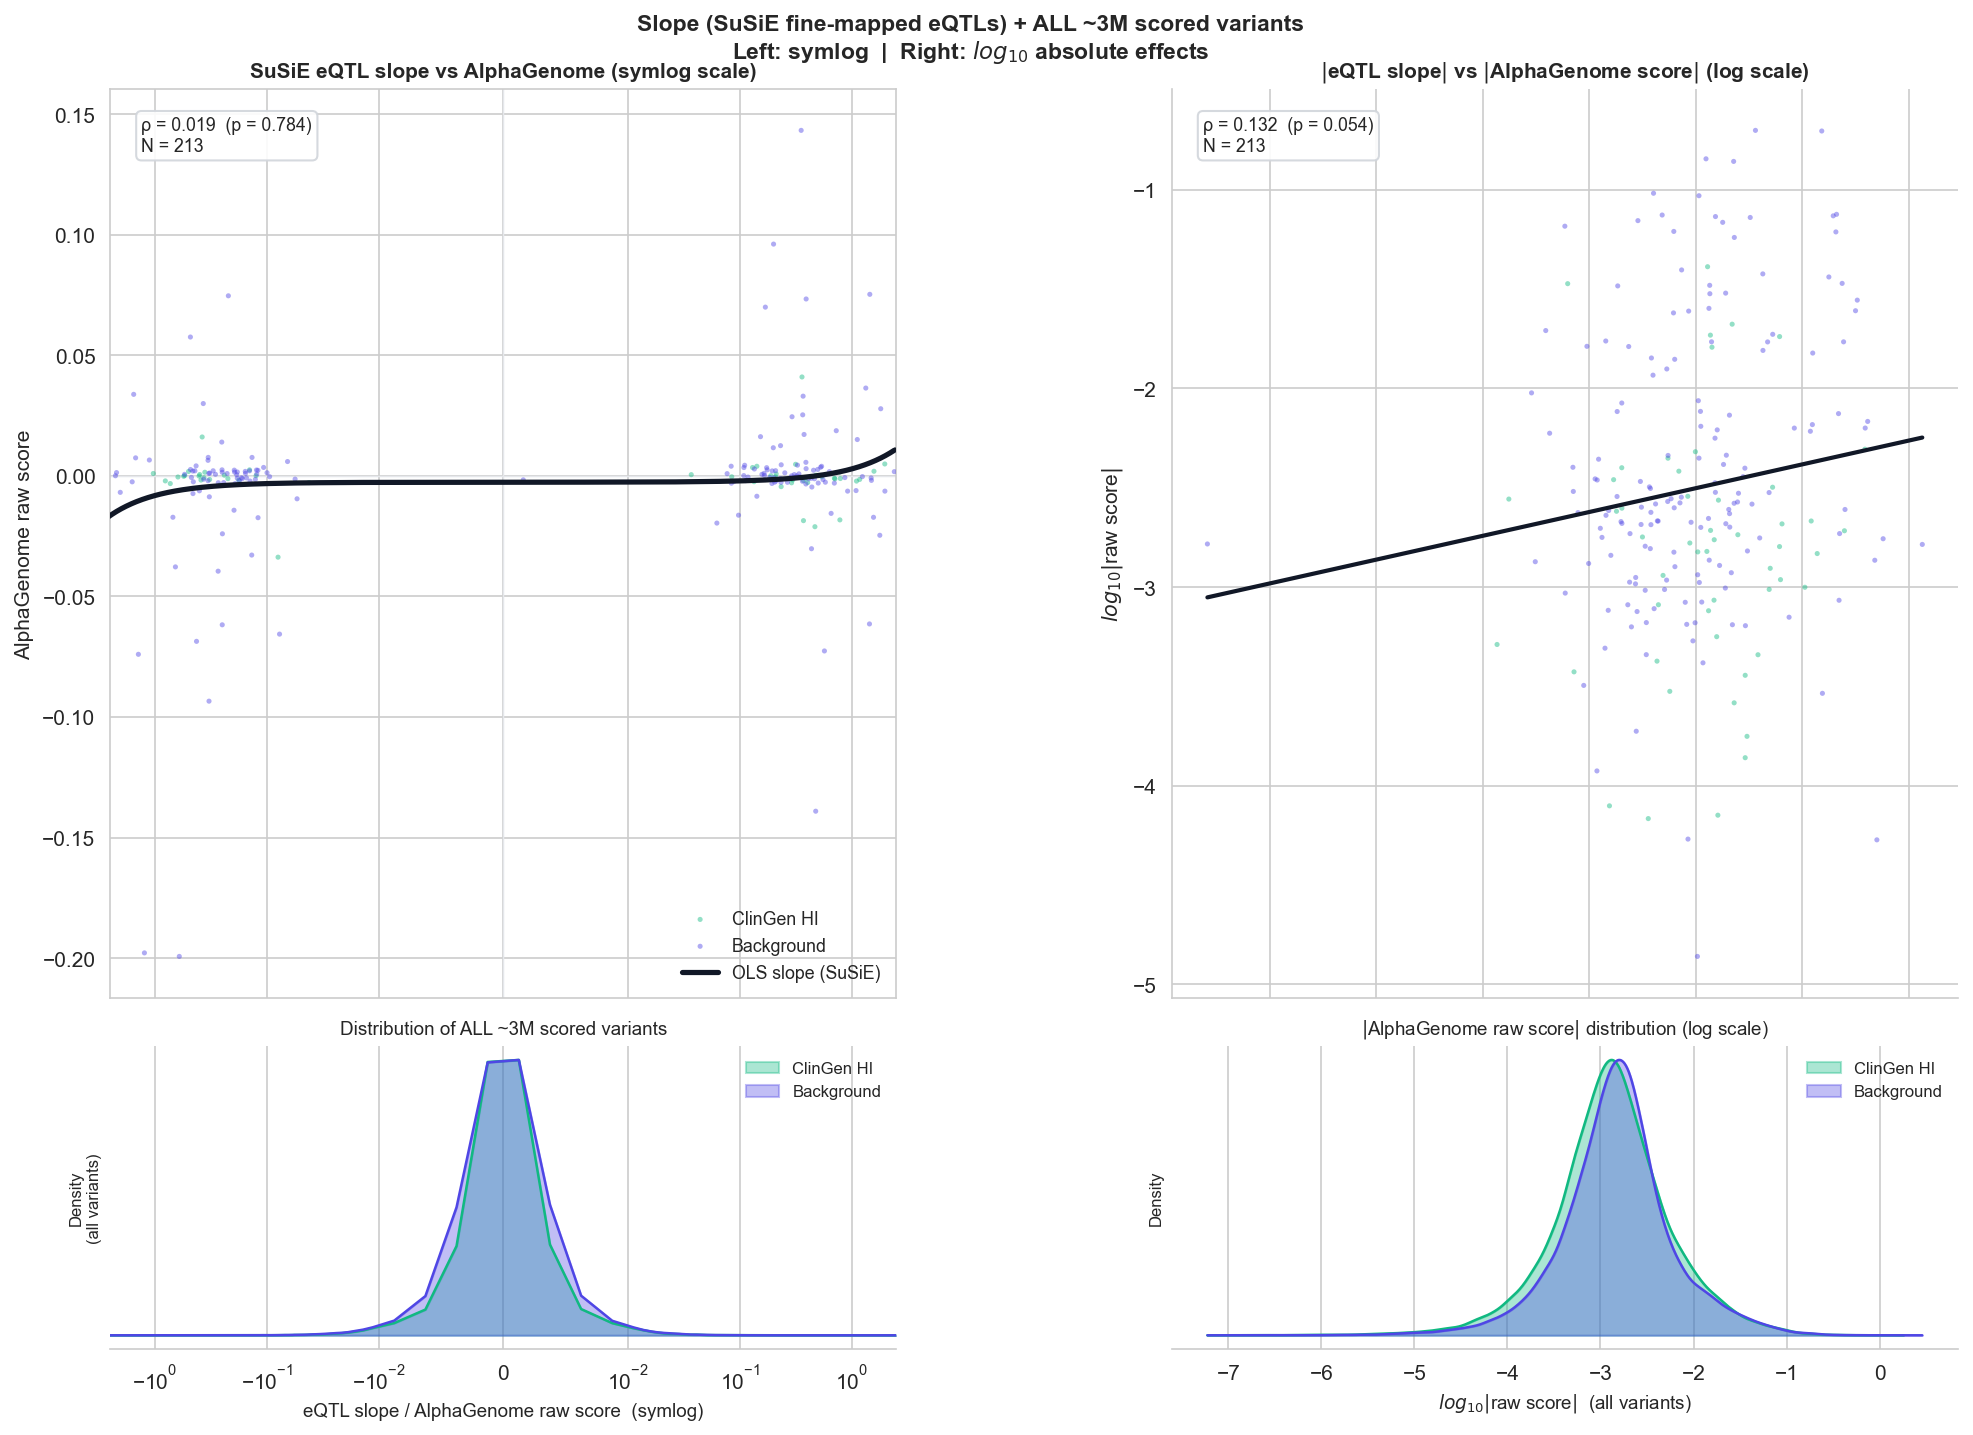

Saved to /Users/markus/master-thesis-lappalainen/in-silico-vg-analysis/10_THESIS/FIGURES_FOR_THESIS/05_slope_all_variants_symlog_loglog.*


In [72]:
from scipy.stats import gaussian_kde

all_raw = {}
for label, path in [('ClinGen HI', VARIANT_PATHS['clingen']),
                    ('Background',  VARIANT_PATHS['background'])]:
    arr = (
        pl.scan_parquet(path)
        .select(['variant_id', 'raw_score'])
        .collect()
        .with_columns(pl.col('raw_score').abs().alias('abs_score'))
        .sort('abs_score', descending=True)
        .group_by('variant_id')
        .first()
        .drop('abs_score')
        ['raw_score'].to_numpy()
    )
    all_raw[label] = arr
    print(f'{label}: {len(arr):,} unique positions')

# 2. OLS slope from SuSiE-matched subset
sl, ic, *_ = stats.linregress(df_matched['afc'].values, df_matched['raw_score'].values)
x_susie_min = df_matched['afc'].min()
x_susie_max = df_matched['afc'].max()

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[3, 1],
    hspace=0.08, wspace=0.35,
    left=0.09, right=0.97, top=0.93, bottom=0.09
)

ax_scatter_sym = fig.add_subplot(gs[0, 0])   # top-left: symlog scatter + slope
ax_kde_sym     = fig.add_subplot(gs[1, 0], sharex=ax_scatter_sym)  # bottom-left: KDE strip
ax_scatter_log = fig.add_subplot(gs[0, 1])   # top-right: log|raw| vs |afc|
ax_kde_log     = fig.add_subplot(gs[1, 1])   # bottom-right: log|raw| density

# Scatter: SuSiE-matched variants (signed)
for grp, color in [('ClinGen HI', COLOR_HI), ('Background', COLOR_BG)]:
    sub = df_matched[df_matched['group'] == grp]
    ax_scatter_sym.scatter(sub['afc'], sub['raw_score'],
                           color=color, s=6, alpha=0.45, edgecolors='none',
                           label=grp, zorder=3)

# OLS slope — solid within data range, dashed outside
X_LO, X_HI = -2.5, 2.5
slope_x_solid = np.linspace(x_susie_min, x_susie_max, 300)
ax_scatter_sym.plot(slope_x_solid, sl*slope_x_solid + ic,
                    color='#111827', lw=2.5, zorder=7, label='OLS slope (SuSiE)')
for x0, x1 in [(X_LO, x_susie_min), (x_susie_max, X_HI)]:
    if x0 < x1:
        xd = np.linspace(x0, x1, 200)
        ax_scatter_sym.plot(xd, sl*xd + ic, color='#111827', lw=2.0, ls='--', zorder=7)

ax_scatter_sym.axhline(0, color='#E5E7EB', lw=0.7, zorder=1)
ax_scatter_sym.axvline(0, color='#E5E7EB', lw=0.7, zorder=1)
ax_scatter_sym.set_xscale('symlog', linthresh=0.01)
ax_scatter_sym.set_xlim(X_LO, X_HI)
ax_scatter_sym.set_ylabel('AlphaGenome raw score', fontsize=10)
ax_scatter_sym.legend(fontsize=8.5, frameon=False)
r_all, p_all, ps_all = signed_rho(df_matched['afc'].values, df_matched['raw_score'].values)
ax_scatter_sym.text(0.04, 0.97,
    f'ρ = {r_all:.3f}  ({ps_all})\nN = {len(df_matched):,}',
    transform=ax_scatter_sym.transAxes, va='top', fontsize=8.5,
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#D1D5DB', alpha=0.9))
ax_scatter_sym.set_title('SuSiE eQTL slope vs AlphaGenome (symlog scale)', fontsize=10, fontweight='bold')
ax_scatter_sym.tick_params(labelbottom=False)

x_kde = np.linspace(X_LO, X_HI, 2000)
for label, color in [('ClinGen HI', COLOR_HI), ('Background', COLOR_BG)]:
    arr = all_raw[label]
    sample = arr[::max(1, len(arr)//50000)]  # downsample for KDE speed
    kde_y = gaussian_kde(sample, bw_method='scott')(x_kde)
    kde_y = kde_y / kde_y.max()
    ax_kde_sym.fill_between(x_kde, kde_y, alpha=0.35, color=color, label=label)
    ax_kde_sym.plot(x_kde, kde_y, color=color, lw=1.2)

ax_kde_sym.set_xscale('symlog', linthresh=0.01)
ax_kde_sym.set_xlim(X_LO, X_HI)
ax_kde_sym.set_xlabel('eQTL slope / AlphaGenome raw score  (symlog)', fontsize=9)
ax_kde_sym.set_ylabel('Density\n(all variants)', fontsize=8)
ax_kde_sym.set_yticks([])
ax_kde_sym.set_title('Distribution of ALL ~3M scored variants', fontsize=9)
ax_kde_sym.legend(fontsize=8, frameon=False)
sns.despine(ax=ax_kde_sym, left=True)

#  Right column: LOG10 absolute scale
# Only variants with nonzero afc and nonzero raw_score
df_abs = df_matched[(df_matched['afc'].abs() > 0) & (df_matched['raw_score'].abs() > 0)].copy()
df_abs['log_abs_afc'] = np.log10(df_abs['afc'].abs())
df_abs['log_abs_raw'] = np.log10(df_abs['raw_score'].abs())

for grp, color in [('ClinGen HI', COLOR_HI), ('Background', COLOR_BG)]:
    sub = df_abs[df_abs['group'] == grp]
    ax_scatter_log.scatter(sub['log_abs_afc'], sub['log_abs_raw'],
                           color=color, s=6, alpha=0.45, edgecolors='none', zorder=3)

if len(df_abs) >= 5:
    sl2, ic2, *_ = stats.linregress(df_abs['log_abs_afc'], df_abs['log_abs_raw'])
    xr2 = np.linspace(df_abs['log_abs_afc'].min(), df_abs['log_abs_afc'].max(), 200)
    ax_scatter_log.plot(xr2, sl2*xr2 + ic2, color='#111827', lw=2.0, zorder=7)
    r_log, p_log, ps_log = signed_rho(df_abs['log_abs_afc'], df_abs['log_abs_raw'])
    ax_scatter_log.text(0.04, 0.97,
        f'ρ = {r_log:.3f}  ({ps_log})\nN = {len(df_abs):,}',
        transform=ax_scatter_log.transAxes, va='top', fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#D1D5DB', alpha=0.9))

ax_scatter_log.set_ylabel(r'$log_{10}|$raw score$|$', fontsize=10)
ax_scatter_log.set_title(r'$|$eQTL slope$|$ vs $|$AlphaGenome score$|$ (log scale)', fontsize=10, fontweight='bold')
ax_scatter_log.tick_params(labelbottom=False)
sns.despine(ax=ax_scatter_log)

# KDE of |raw_score| on log scale — all scored variants
for label, color in [('ClinGen HI', COLOR_HI), ('Background', COLOR_BG)]:
    arr = all_raw[label]
    abs_nonzero = np.abs(arr[arr != 0])
    log_arr = np.log10(abs_nonzero[abs_nonzero > 0])
    sample = log_arr[::max(1, len(log_arr)//50000)]
    kde2 = gaussian_kde(sample, bw_method='scott')
    x_log_kde = np.linspace(log_arr.min(), log_arr.max(), 1000)
    kde2_y = kde2(x_log_kde)
    kde2_y = kde2_y / kde2_y.max()
    ax_kde_log.fill_between(x_log_kde, kde2_y, alpha=0.35, color=color, label=label)
    ax_kde_log.plot(x_log_kde, kde2_y, color=color, lw=1.2)

ax_kde_log.set_xlabel(r'$log_{10}|$raw score$|$  (all variants)', fontsize=9)
ax_kde_log.set_ylabel('Density', fontsize=8)
ax_kde_log.set_yticks([])
ax_kde_log.set_title(r'$|$AlphaGenome raw score$|$ distribution (log scale)', fontsize=9)
ax_kde_log.legend(fontsize=8, frameon=False)
sns.despine(ax=ax_kde_log, left=True)

fig.suptitle(
    'Slope (SuSiE fine-mapped eQTLs) + ALL ~3M scored variants\n'
    'Left: symlog  |  Right: $log_{10}$ absolute effects',
    fontsize=11, fontweight='bold', y=0.98
)

save_plot(fig=fig, title='05_slope_all_variants_symlog_loglog', notebook=NOTEBOOK_NAME, outdir=FIG_DIR)
plt.show()
print(f'Saved to {FIG_DIR}/05_slope_all_variants_symlog_loglog.*')

## 4. Score concordance by gene set  
Marli slide 10 — variant-level, expected ρ ≈ 0.02)*

by group (ClinGen HI, Background) and extreme AlphaGenome scores.
Marlis's genome-wide analysis had ρ ≈ 0.021–0.023 across all score summaries.  
With n=213 total our estimates are noisy but directionally consistent.  

**Note on CS-level replication:** Marlis showed CS-level aggregation boosting ρ from 0.02 → 0.44.  
now we cannot replicate this: our SuSiE parquet contains only **7 unique credible sets** in the
gene-set overlap region, far too few for the PIP × quantile sweep analysis.  
The gene-level Vg analysis (Section 5 below) serves as our aggregation-level comparison instead.

[save_plot] Saved: 05_marlis_comparison_05_slide10_variant_level_concordance_24042026_2234.pdf
[save_plot] Saved: 05_marlis_comparison_05_slide10_variant_level_concordance_24042026_2234.svg


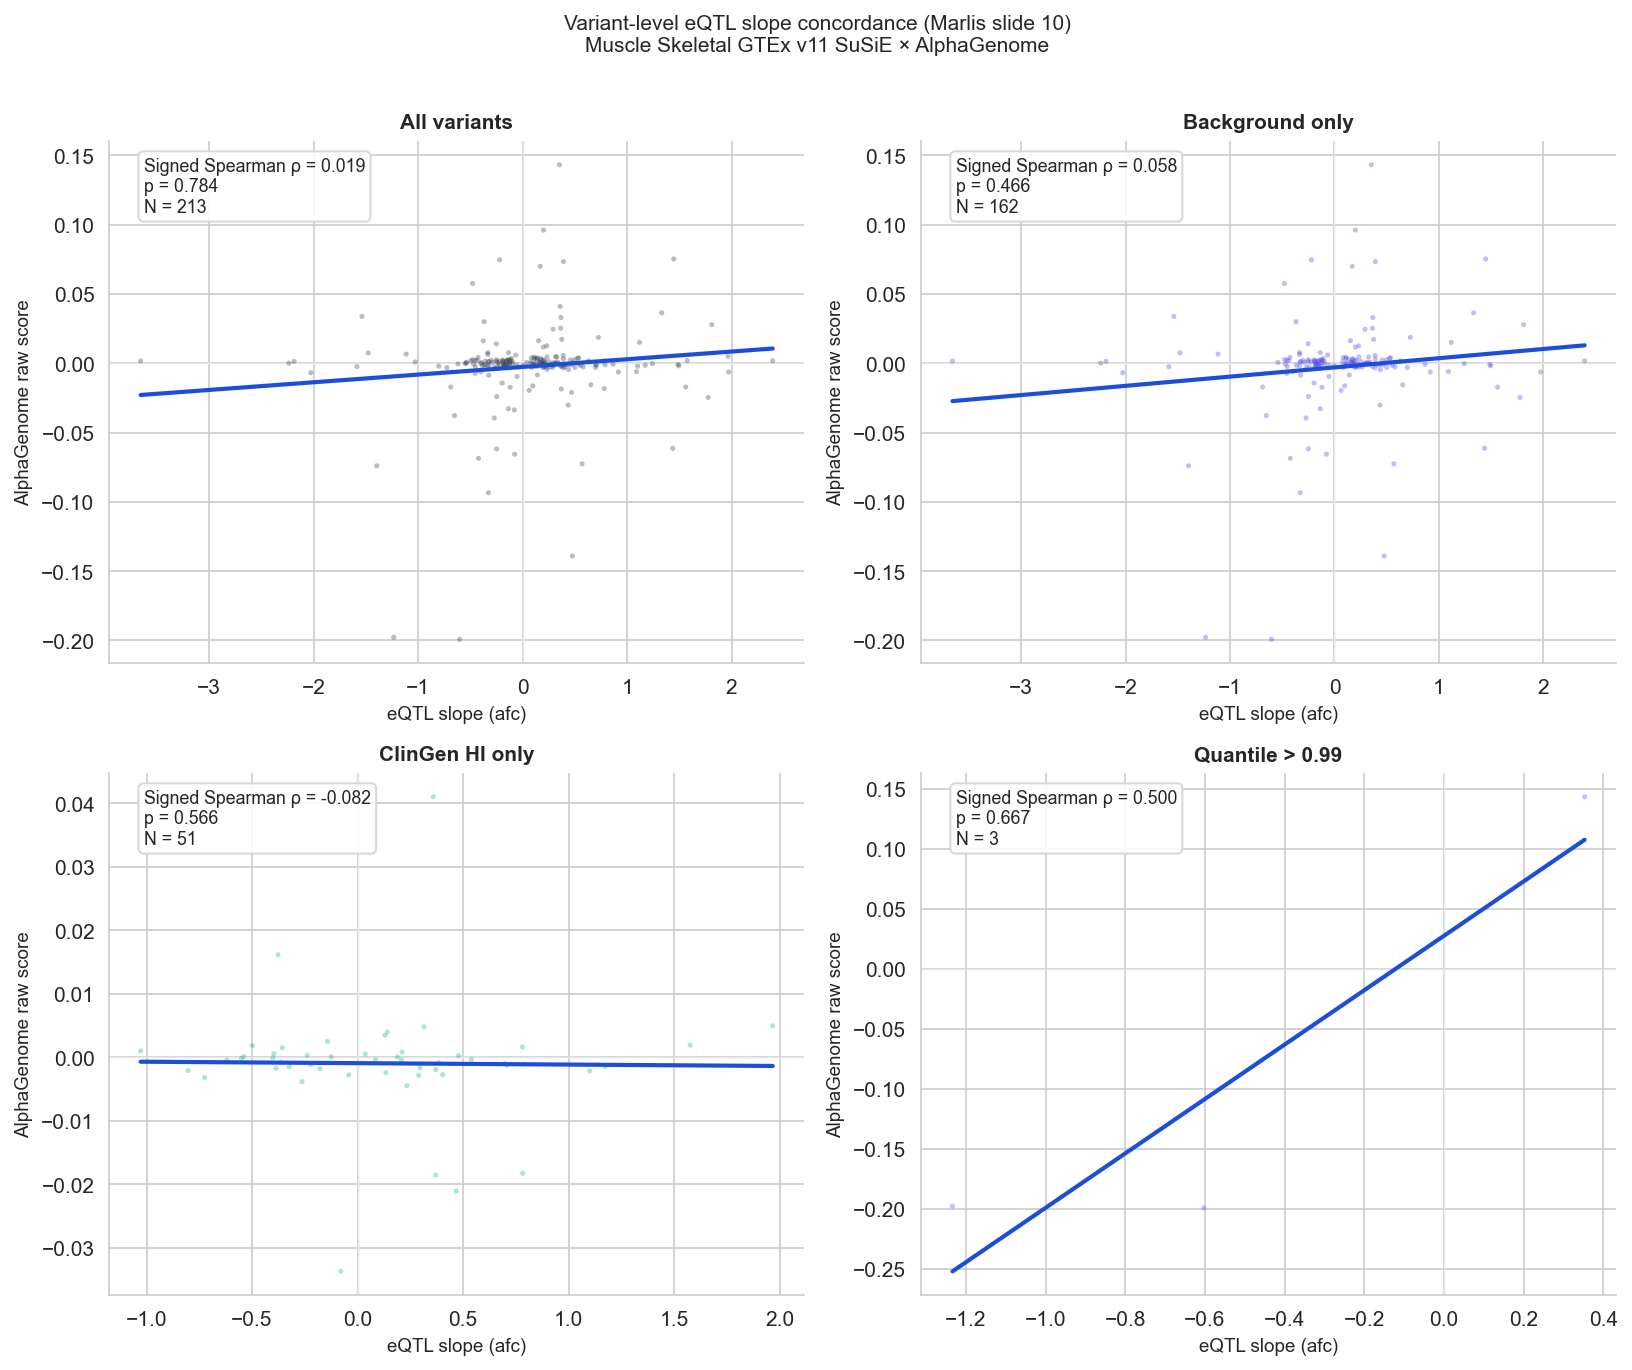

In [65]:
# 4-panel: all / BG only / HI only / quantile>0.99
# x = eQTL afc, y = AlphaGenome raw_score
panels = [
    ('All variants',         df_matched,  '#374151'),
    ('Background only',      df_bg_m,     COLOR_BG),
    ('ClinGen HI only',      df_hi_m,     COLOR_HI),
    (f'Quantile > {QUANTILE_THRESH}', df_extreme,  '#7C3AED'),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=False, sharey=False)
axes = axes.flatten()

for ax, (title, data, color) in zip(axes, panels):
    r, p, ps = signed_rho(data['afc'].values, data['raw_score'].values)
    rp, _ = pearsonr(data['afc'].values, data['raw_score'].values)
    ax.scatter(data['afc'], data['raw_score'],
               color=color, s=6, alpha=0.35, edgecolors='none', zorder=2)
    sl, ic, *_ = stats.linregress(data['afc'], data['raw_score'])
    xr = np.linspace(data['afc'].min(), data['afc'].max(), 200)
    ax.plot(xr, sl*xr+ic, color='#1D4ED8', lw=2.0, zorder=3)
    ax.axhline(0, color='#E5E7EB', lw=0.7, zorder=1)
    ax.axvline(0, color='#E5E7EB', lw=0.7, zorder=1)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('eQTL slope (afc)', fontsize=9)
    ax.set_ylabel('AlphaGenome raw score', fontsize=9)
    ax.text(0.05, 0.97,
            f'Signed Spearman ρ = {r:.3f}\n{ps}\nN = {len(data):,}',
            transform=ax.transAxes, va='top', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#D1D5DB', alpha=0.9))
    sns.despine(ax=ax)

fig.suptitle(
    'Variant-level eQTL slope concordance (Marlis slide 10)\n'
    'Muscle Skeletal GTEx v11 SuSiE × AlphaGenome',
    fontsize=10, y=1.01
)
fig.tight_layout()
save_plot(fig=fig, title='05_slide10_variant_level_concordance', notebook=NOTEBOOK_NAME, outdir=FIG_DIR)
plt.show()

## 5. CS-level aggregation
Marli slides 11–14

The SuSiE parquet has **13,571 unique credible sets** — identified by compound key `(phenotype_id, cs_id)`.  
The previous attempt failed because `cs_id` alone (values 1–7) is the within-gene index only.

**Strategy:**
- CS membership: all 272k SuSiE variants grouped by `(phenotype_id, cs_id)`
- CS eQTL slope: mean `afc` per CS from the 13,568 afc-having rows
- CS AG scores: our ~2.5M scored variants joined to CS member positions, aggregated per CS
- CS quantile: max variant-level quantile (vs all scored variants) within each CS

In [66]:
# Build compound CS key and mean eQTL slope per CS
susie_all_parsed = (
    susie_raw
    .with_columns(
        pl.col('phenotype_id').str.replace(r'\.\d+$', '').alias('gene_id'),
        (pl.col('phenotype_id').str.replace(r'\.\d+$', '') + '_cs' +
         pl.col('cs_id').cast(pl.Utf8)).alias('cs_key'),
        (
            pl.col('variant_id').str.replace_all('_b38$', '')
            .str.splitn('_', 4)
            .struct.rename_fields(['chrom', 'pos', 'ref', 'alt'])
        ).alias('parts')
    )
    .unnest('parts')
    .with_columns(
        (pl.col('chrom') + ':' + pl.col('pos') + ':' +
         pl.col('ref') + '>' + pl.col('alt')).alias('join_key')
    )
)

# CS slope: mean afc per CS (only afc-having rows)
cs_slope_v2 = (
    susie_all_parsed
    .filter(pl.col('afc').is_not_null())
    .group_by('cs_key')
    .agg([
        pl.col('afc').mean().alias('mean_afc'),
        pl.col('pip').max().alias('max_pip'),
        pl.col('pip').mean().alias('mean_pip'),
        pl.len().alias('n_cs_afc_variants'),
    ])
)
print(f"CS with eQTL slope: {cs_slope_v2.height:,}")

# CS membership: all variant positions (for AG join)
cs_members = susie_all_parsed.select(['cs_key', 'join_key', 'pip'])
print(f"CS-variant assignments: {cs_members.height:,}")
print(f"Unique positions in SuSiE: {cs_members['join_key'].n_unique():,}")

CS with eQTL slope: 13,568
CS-variant assignments: 272,555
Unique positions in SuSiE: 223,094


In [67]:
# Compute global variant-level quantile (rank within ALL scored variants)
# then join to CS membership and aggregate per CS

from scipy.stats import rankdata as _rankdata

frames_cs_v2 = []
all_scored_list = []  # collect for global quantile

# First pass: load all AG scores with position dedup
ag_all = {}
for label, path_p in [('ClinGen HI', VARIANT_PATHS['clingen']),
                       ('Background',  VARIANT_PATHS['background'])]:
    arr_df = (
        pl.scan_parquet(path_p)
        .select(['variant_id', 'raw_score'])
        .collect()
        .with_columns(pl.col('raw_score').abs().alias('abs_score'))
        .sort('abs_score', descending=True)
        .group_by('variant_id').first().drop('abs_score')
        .rename({'variant_id': 'join_key'})
        .with_columns(pl.lit(label).alias('group'))
    )
    ag_all[label] = arr_df
    print(f"{label}: {arr_df.height:,} unique positions")

# Global quantile across both gene sets
all_ag = pl.concat(list(ag_all.values()))
abs_vals = all_ag['raw_score'].abs().to_numpy()
global_quantile = _rankdata(abs_vals, method='average') / len(abs_vals)
all_ag = all_ag.with_columns(pl.Series('quantile_score', global_quantile))

print(f"\nGlobal quantile range: [{all_ag['quantile_score'].min():.3f}, {all_ag['quantile_score'].max():.3f}]")

# Second pass: join to CS membership, aggregate per CS
for label in ['ClinGen HI', 'Background']:
    ag = all_ag.filter(pl.col('group') == label)
    ag_cs = ag.join(cs_members, on='join_key', how='inner')
    print(f"\n{label}: {ag.height:,} scored → {ag_cs.height:,} CS-variant matches "
          f"across {ag_cs['cs_key'].n_unique():,} unique CS")

    # Aggregate per CS
    cs_ag_grp = (
        ag_cs.group_by('cs_key')
        .agg([
            pl.col('raw_score').max().alias('max_raw_score'),
            pl.col('raw_score').mean().alias('mean_raw_score'),
            pl.col('raw_score').median().alias('median_raw_score'),
            (pl.col('raw_score').pow(2).sum().sqrt()).alias('_l2'),
            pl.col('raw_score').sum().alias('sum_raw_score'),
            pl.col('quantile_score').max().alias('max_quantile'),
            pl.len().alias('n_scored_variants'),
        ])
        .with_columns([
            (pl.col('max_raw_score').sign() * pl.col('_l2')).alias('signed_l2_by_max'),
            pl.lit(label).alias('group'),
        ])
        .drop('_l2')
    )
    frames_cs_v2.append(cs_ag_grp)

cs_ag_all_v2 = pl.concat(frames_cs_v2)
cs_df_v2 = cs_ag_all_v2.join(cs_slope_v2, on='cs_key', how='inner').to_pandas()
cs_hi_v2 = cs_df_v2[cs_df_v2['group'] == 'ClinGen HI']
cs_bg_v2 = cs_df_v2[cs_df_v2['group'] == 'Background']

print(f"\nCS-level table: {len(cs_df_v2):,} rows  (HI: {len(cs_hi_v2):,}, BG: {len(cs_bg_v2):,})")
print(f"Quantile > 0.99: {(cs_df_v2['max_quantile'] > 0.99).sum():,} CS")
print(cs_df_v2[['mean_afc', 'max_raw_score', 'mean_raw_score', 'max_quantile']].describe().round(3))

ClinGen HI: 1,292,916 unique positions
Background: 1,308,193 unique positions

Global quantile range: [0.000, 1.000]

ClinGen HI: 1,292,916 scored → 899 CS-variant matches across 205 unique CS

Background: 1,308,193 scored → 1,819 CS-variant matches across 409 unique CS

CS-level table: 614 rows  (HI: 205, BG: 409)
Quantile > 0.99: 58 CS
       mean_afc  max_raw_score  mean_raw_score  max_quantile
count   614.000        614.000         614.000       614.000
mean      0.038          0.007          -0.000         0.726
std       0.623          0.028           0.019         0.260
min      -3.657         -0.199          -0.199         0.004
25%      -0.249          0.000          -0.001         0.575
50%       0.058          0.002           0.000         0.803
75%       0.323          0.006           0.001         0.949
max       4.330          0.212           0.119         0.999


[save_plot] Saved: 05_marlis_comparison_05_cs_level_all_24042026_2234.pdf
[save_plot] Saved: 05_marlis_comparison_05_cs_level_all_24042026_2234.svg


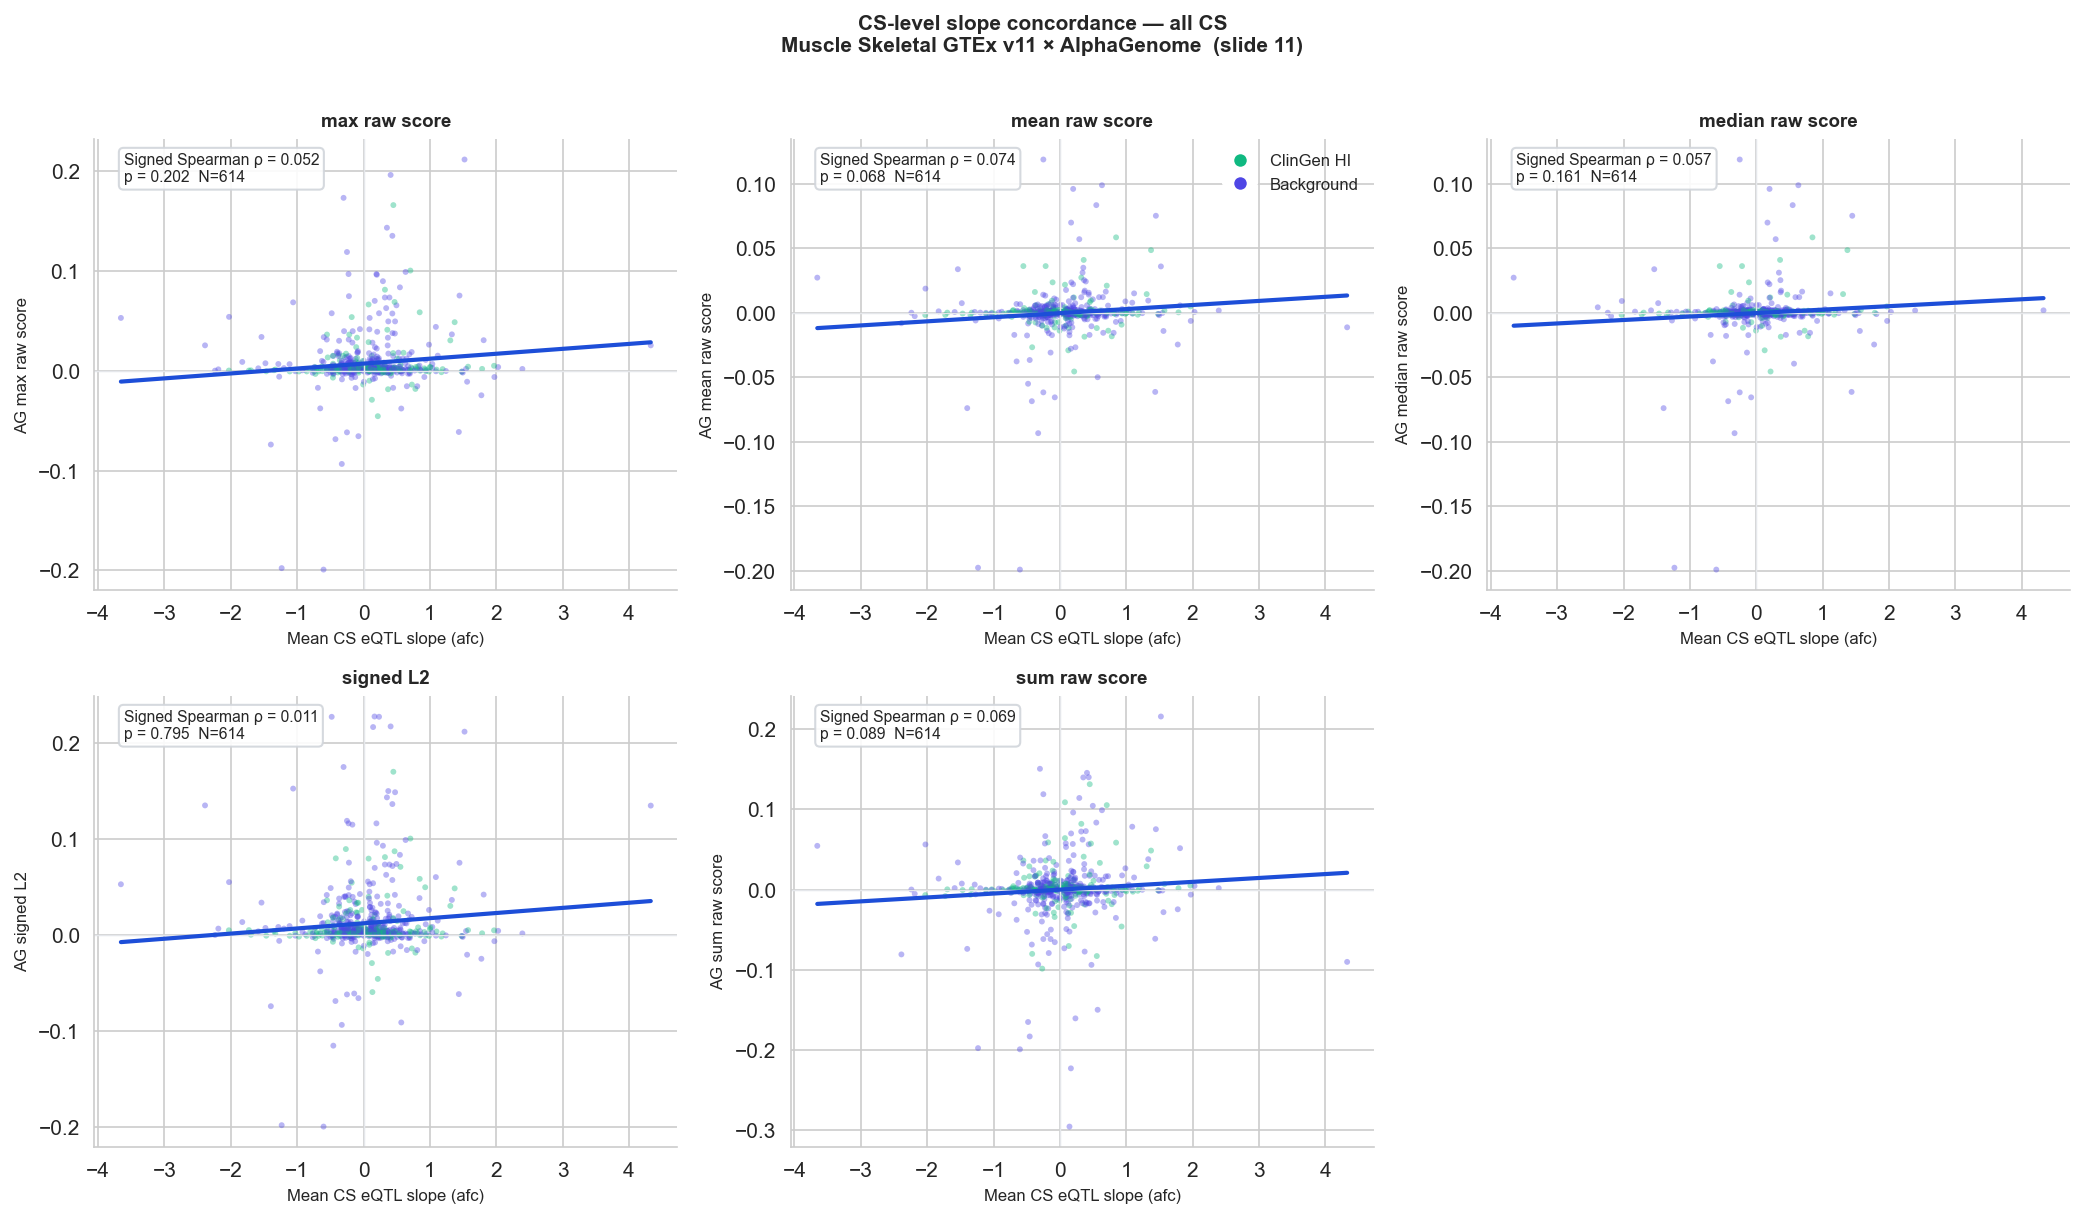

[save_plot] Saved: 05_marlis_comparison_05_cs_level_q99_24042026_2234.pdf
[save_plot] Saved: 05_marlis_comparison_05_cs_level_q99_24042026_2234.svg


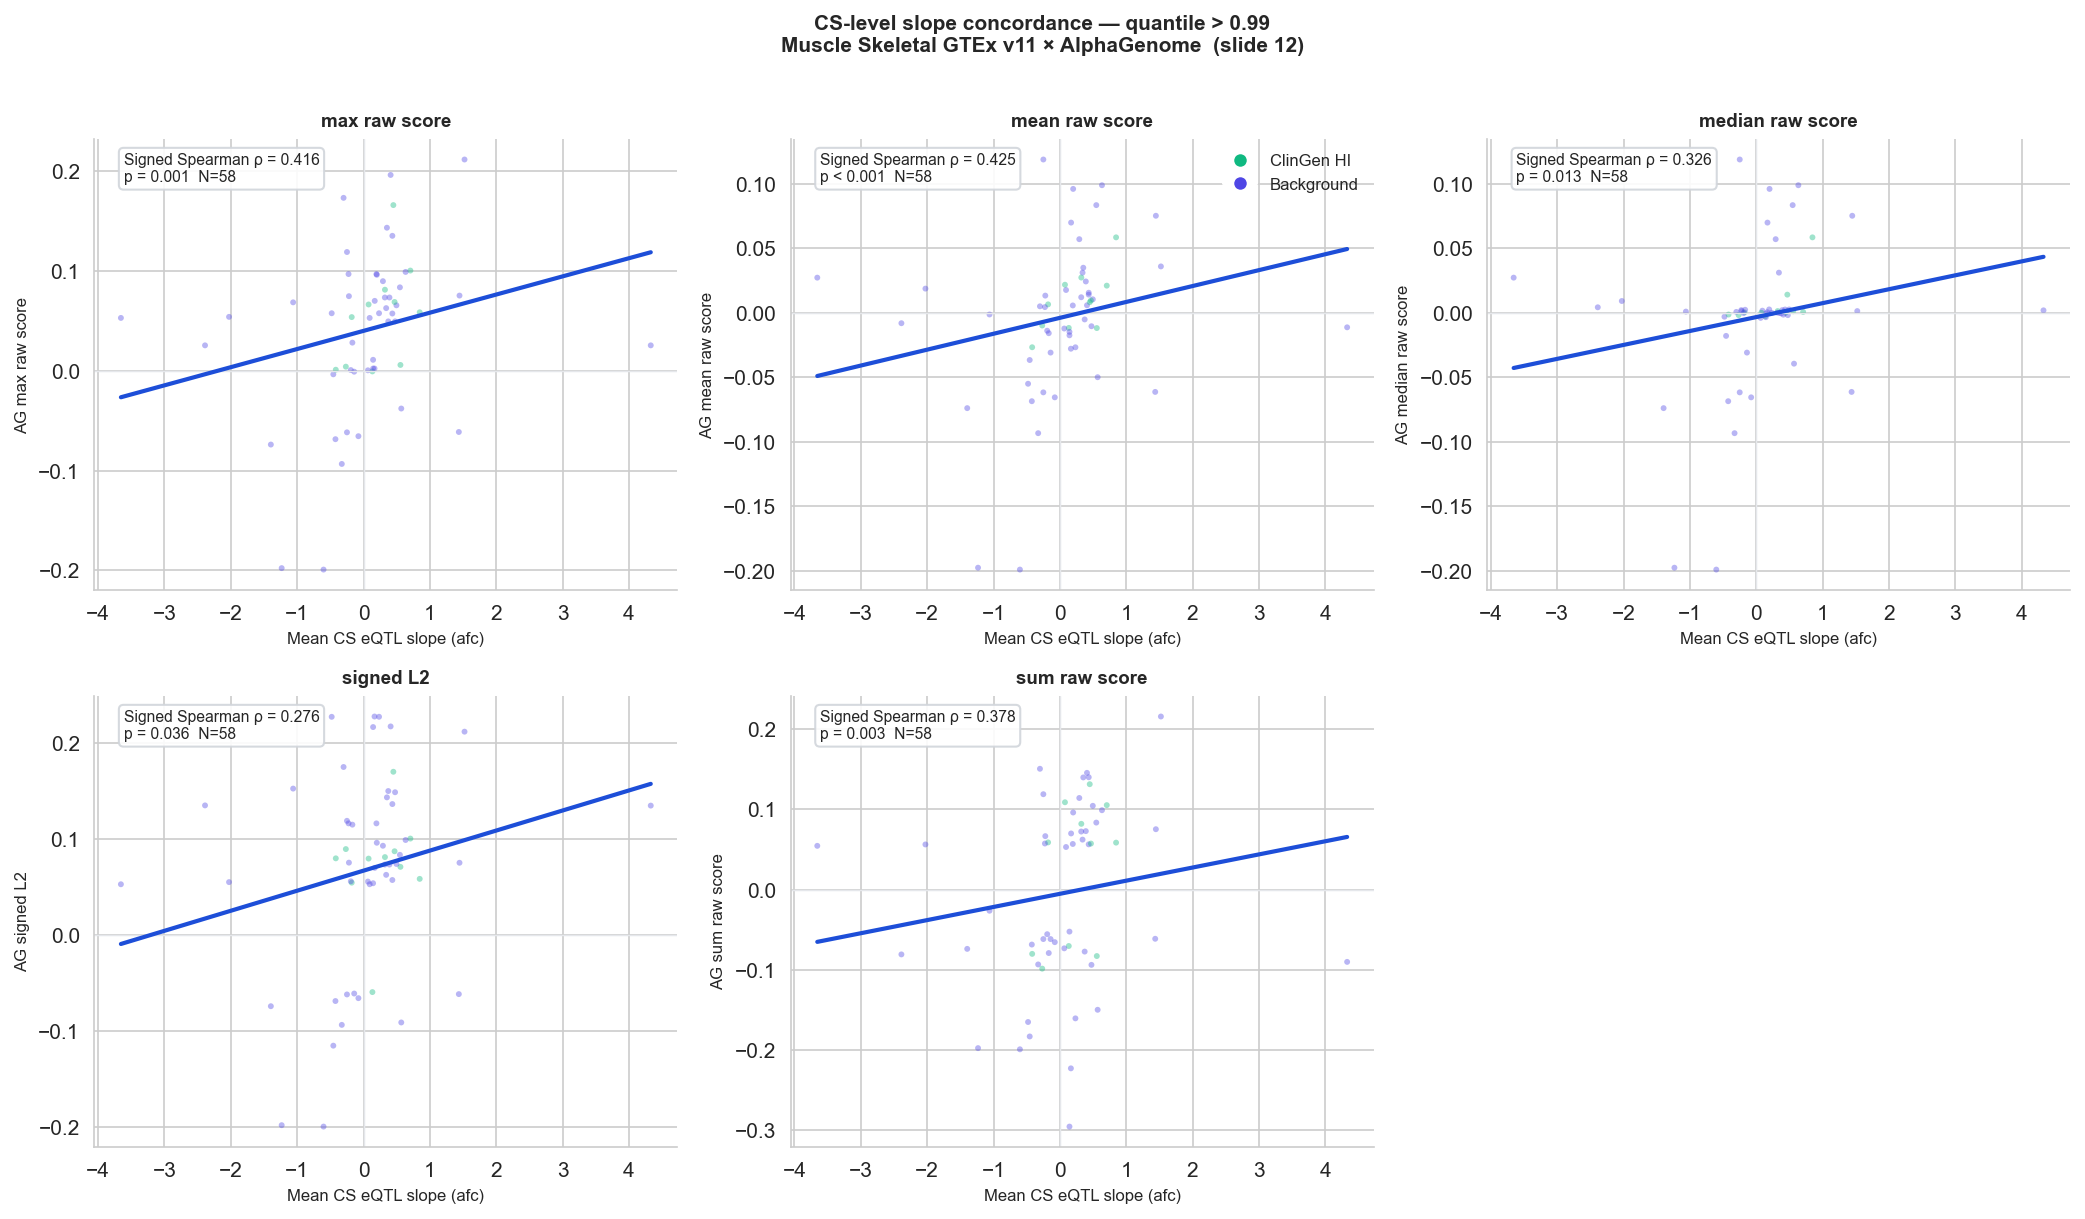

[save_plot] Saved: 05_marlis_comparison_05_cs_level_pip02_q99_24042026_2234.pdf
[save_plot] Saved: 05_marlis_comparison_05_cs_level_pip02_q99_24042026_2234.svg


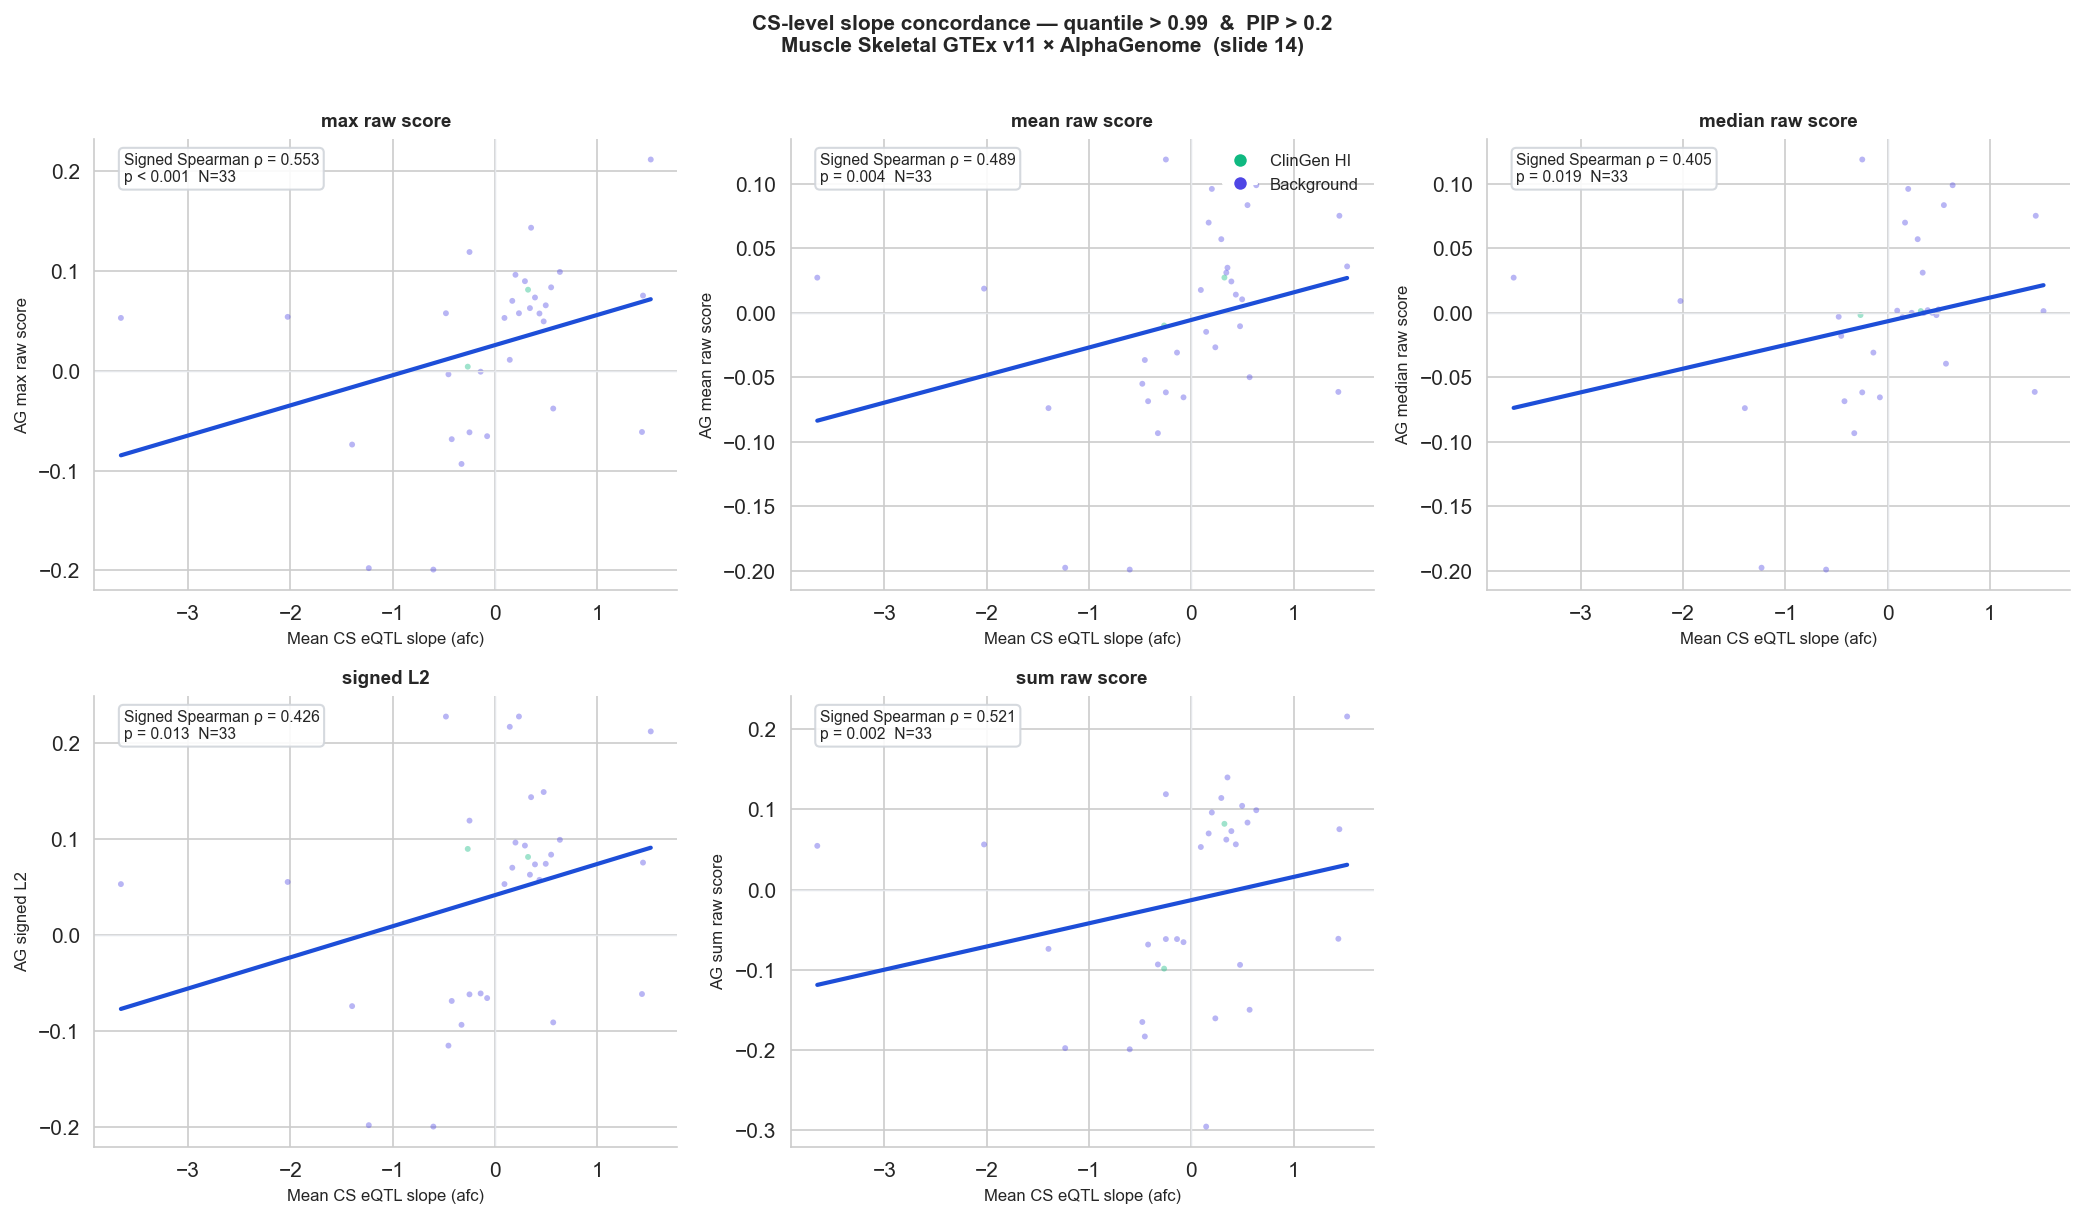

In [68]:
SCORE_SUMMARIES_CS = [
    ('max_raw_score',    'max raw score'),
    ('mean_raw_score',   'mean raw score'),
    ('median_raw_score', 'median raw score'),
    ('signed_l2_by_max', 'signed L2'),
    ('sum_raw_score',    'sum raw score'),
]

def plot_cs_v2(data, title_suffix, pip_thresh=None, quant_thresh=None, save_key=None):
    sub = data.copy()
    if pip_thresh is not None:
        sub = sub[sub['max_pip'] >= pip_thresh]
    if quant_thresh is not None:
        sub = sub[sub['max_quantile'] >= quant_thresh]

    cond_parts = []
    if quant_thresh: cond_parts.append(f'quantile > {quant_thresh}')
    if pip_thresh:   cond_parts.append(f'PIP > {pip_thresh}')
    cond_str = '  &  '.join(cond_parts) if cond_parts else 'all CS'

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes_flat = axes.flatten()

    for i, (col, label) in enumerate(SCORE_SUMMARIES_CS):
        ax = axes_flat[i]
        d = sub[sub[col].notna() & sub['mean_afc'].notna()]
        if len(d) < 5:
            ax.text(0.5, 0.5, f'n={len(d)} (too few)', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9)
            ax.set_title(label, fontsize=9)
            continue
        r, p, ps = signed_rho(d['mean_afc'].values, d[col].values)
        hue = d['group'].map({'ClinGen HI': COLOR_HI, 'Background': COLOR_BG})
        ax.scatter(d['mean_afc'], d[col], c=hue, s=8, alpha=0.4, edgecolors='none', zorder=2)
        sl, ic, *_ = stats.linregress(d['mean_afc'].values, d[col].values)
        xr = np.linspace(d['mean_afc'].min(), d['mean_afc'].max(), 200)
        ax.plot(xr, sl*xr+ic, color='#1D4ED8', lw=2.0, zorder=3)
        ax.axhline(0, color='#E5E7EB', lw=0.7); ax.axvline(0, color='#E5E7EB', lw=0.7)
        ax.set_title(label, fontsize=9, fontweight='bold')
        ax.set_xlabel('Mean CS eQTL slope (afc)', fontsize=8)
        ax.set_ylabel(f'AG {label}', fontsize=8)
        ax.text(0.05, 0.97, f'Signed Spearman ρ = {r:.3f}\n{ps}  N={len(d):,}',
                transform=ax.transAxes, va='top', fontsize=7.5,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#D1D5DB', alpha=0.9))
        sns.despine(ax=ax)

    axes_flat[-1].set_visible(False)
    # Legend
    from matplotlib.lines import Line2D
    leg = [Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_HI, markersize=7, label='ClinGen HI'),
           Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_BG, markersize=7, label='Background')]
    axes_flat[1].legend(handles=leg, frameon=False, fontsize=8, loc='upper right')

    fig.suptitle(
        f'CS-level slope concordance — {cond_str}\n'
        f'Muscle Skeletal GTEx v11 × AlphaGenome  {title_suffix}',
        fontsize=10, fontweight='bold', y=1.01
    )
    fig.tight_layout()
    if save_key:
        save_plot(fig=fig, title=save_key, notebook=NOTEBOOK_NAME, outdir=FIG_DIR)
    plt.show()
    return fig

# Slide 11: all CS
fig11 = plot_cs_v2(cs_df_v2, '(slide 11)', save_key='05_cs_level_all')

# Slide 12: quantile > 0.99
fig12 = plot_cs_v2(cs_df_v2, '(slide 12)', quant_thresh=0.99, save_key='05_cs_level_q99')

# Slide 14: PIP > 0.2 + quantile > 0.99
fig14 = plot_cs_v2(cs_df_v2, '(slide 14)', pip_thresh=0.2, quant_thresh=0.99, save_key='05_cs_level_pip02_q99')

Sweep: 100 combinations
 quantile_thresh  pip_cutoff    score_summary      rho        p  n
           0.995         0.8    sum_raw_score 0.771429 0.072397  6
           0.995         0.8 median_raw_score 0.771429 0.072397  6
           0.995         0.8   mean_raw_score 0.771429 0.072397  6
           0.995         0.5 median_raw_score 0.750000 0.019942  9
           0.995         0.5   mean_raw_score 0.750000 0.019942  9
           0.995         0.2    max_raw_score 0.746781 0.000573 17
           0.990         0.8   mean_raw_score 0.733333 0.015801 10
           0.990         0.8 median_raw_score 0.733333 0.015801 10
           0.990         0.8    sum_raw_score 0.721212 0.018573 10
           0.995         0.5 signed_l2_by_max 0.716667 0.029818  9
[save_plot] Saved: 05_marlis_comparison_05_cs_sweep_pip_quantile_24042026_2234.pdf
[save_plot] Saved: 05_marlis_comparison_05_cs_sweep_pip_quantile_24042026_2234.svg


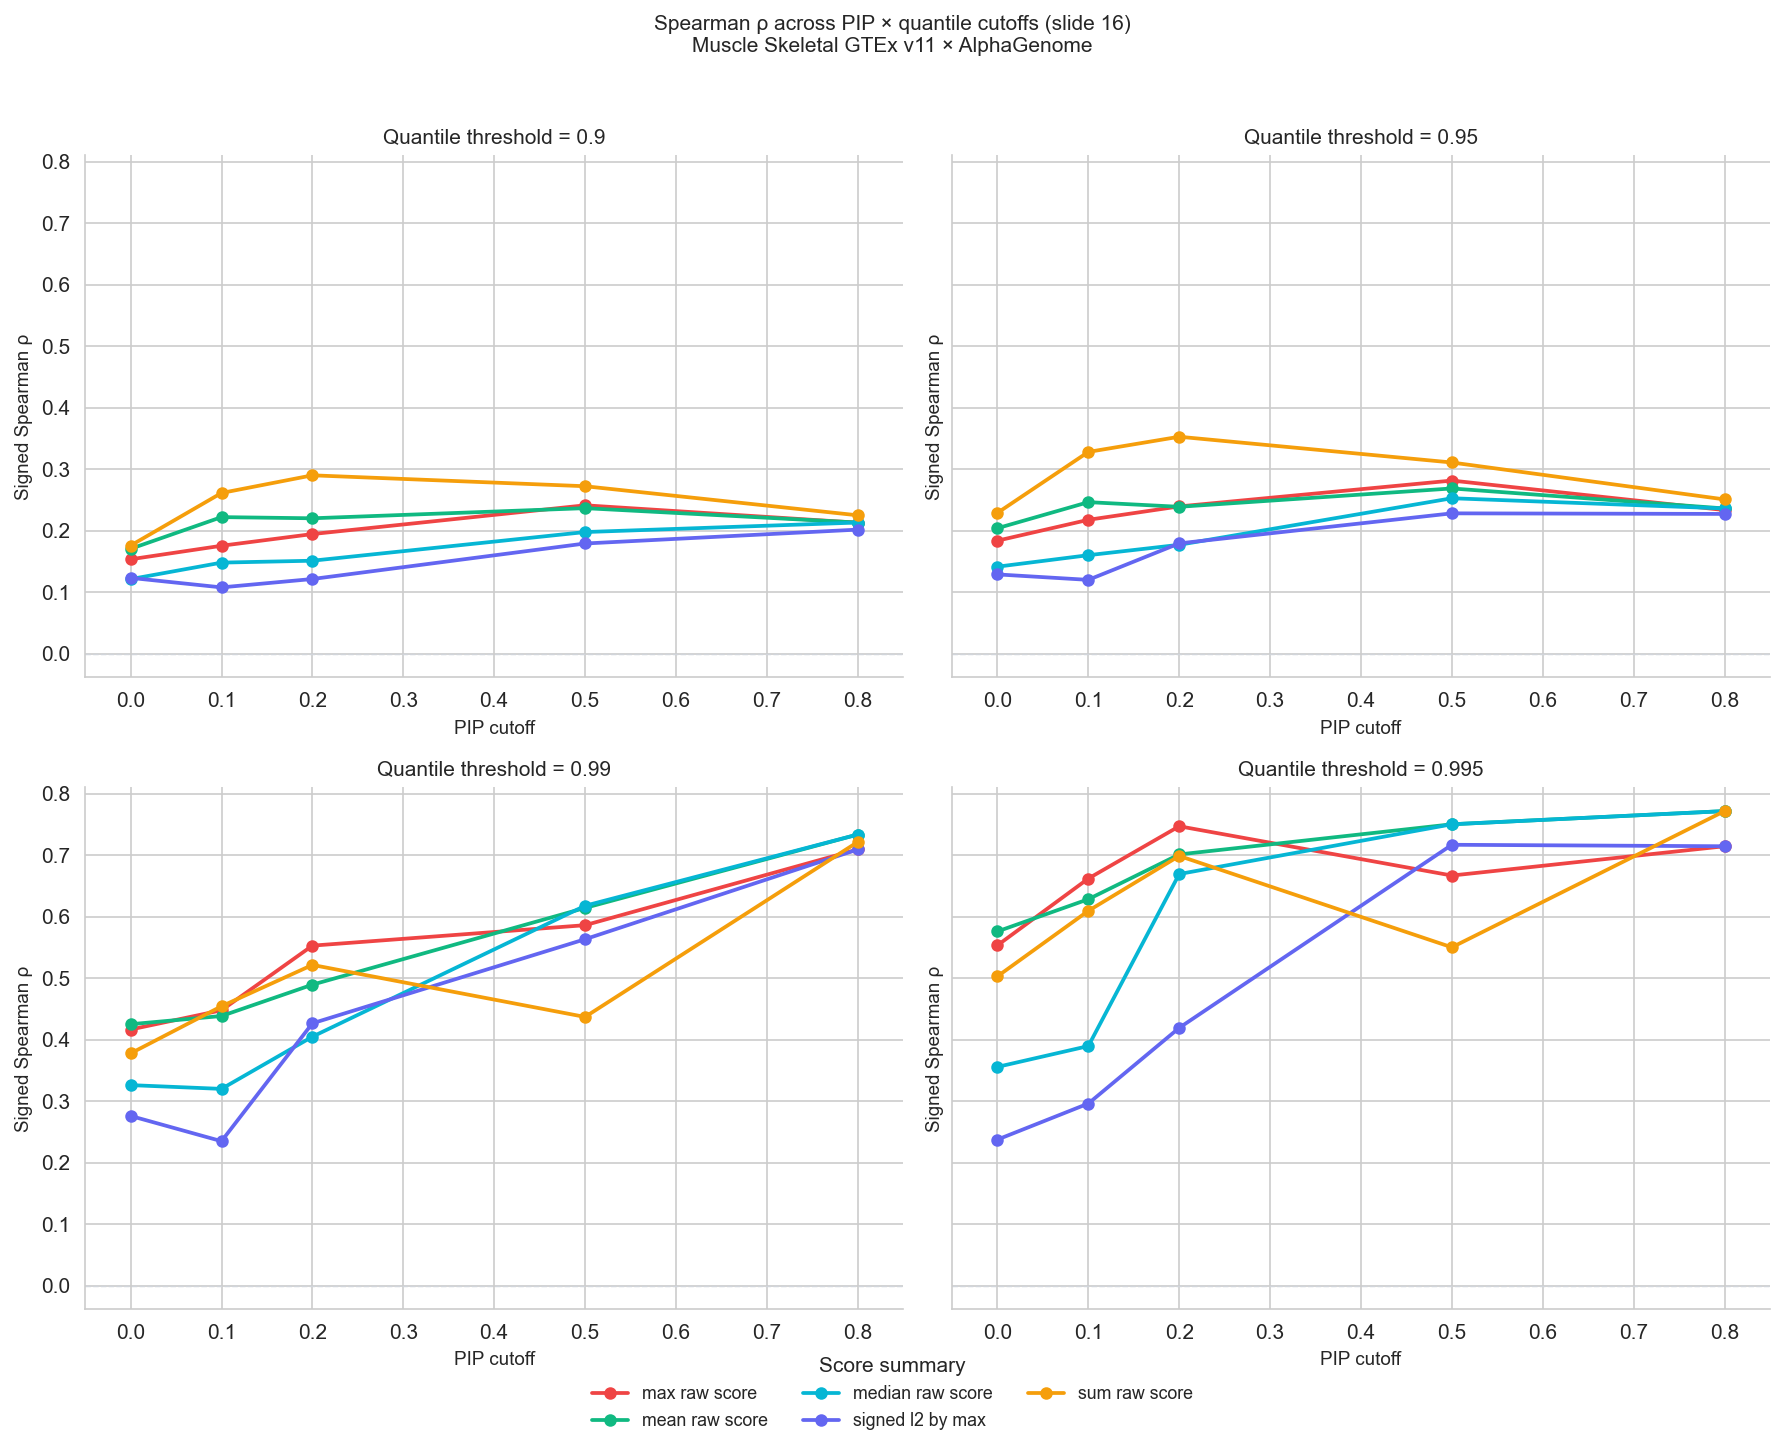

In [69]:
# Spearman rho across PIP × quantile cutoffs (slide 16)
QUANTILE_THRESHOLDS = [0.9, 0.95, 0.99, 0.995]
PIP_CUTOFFS = [0.0, 0.1, 0.2, 0.5, 0.8]

SCORE_PALETTE_CS = {
    'max_raw_score':    '#EF4444',
    'mean_raw_score':   '#10B981',
    'median_raw_score': '#06B6D4',
    'signed_l2_by_max': '#6366F1',
    'sum_raw_score':    '#F59E0B',
}

results_sweep = []
for qt in QUANTILE_THRESHOLDS:
    dq = cs_df_v2[cs_df_v2['max_quantile'] >= qt]
    for pip_cut in PIP_CUTOFFS:
        dqp = dq[dq['max_pip'] >= pip_cut]
        if len(dqp) < 5:
            continue
        for col, _ in SCORE_SUMMARIES_CS:
            d = dqp[dqp[col].notna() & dqp['mean_afc'].notna()]
            if len(d) < 5:
                continue
            r, p, ps = signed_rho(d['mean_afc'].values, d[col].values)
            results_sweep.append({'quantile_thresh': qt, 'pip_cutoff': pip_cut,
                                   'score_summary': col, 'rho': r, 'p': p, 'n': len(d)})

df_sweep_v2 = pd.DataFrame(results_sweep)
if df_sweep_v2.empty:
    print("Sweep produced 0 combinations — n too small after filtering.")
else:
    print(f"Sweep: {len(df_sweep_v2)} combinations")
    print(df_sweep_v2.sort_values('rho', ascending=False).head(10).to_string(index=False))

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
    for ax, qt in zip(axes.flatten(), QUANTILE_THRESHOLDS):
        for score_col, color in SCORE_PALETTE_CS.items():
            sub = df_sweep_v2[(df_sweep_v2['quantile_thresh'] == qt) &
                               (df_sweep_v2['score_summary'] == score_col)]
            if sub.empty:
                continue
            ax.plot(sub['pip_cutoff'], sub['rho'], marker='o', color=color,
                    lw=1.8, ms=5, label=score_col.replace('_', ' '))
        ax.axhline(0, color='#D1D5DB', lw=0.7, ls='--')
        ax.set_title(f'Quantile threshold = {qt}', fontsize=10)
        ax.set_xlabel('PIP cutoff', fontsize=9)
        ax.set_ylabel('Signed Spearman ρ', fontsize=9)
        ax.set_xlim(-0.05, 0.85)
        sns.despine(ax=ax)

    handles, labels = axes.flatten()[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False,
               fontsize=8.5, title='Score summary', bbox_to_anchor=(0.5, -0.04))
    fig.suptitle('Spearman ρ across PIP × quantile cutoffs (slide 16)\n'
                 'Muscle Skeletal GTEx v11 × AlphaGenome', fontsize=10, y=1.02)
    fig.tight_layout()
    save_plot(fig=fig, title='05_cs_sweep_pip_quantile', notebook=NOTEBOOK_NAME, outdir=FIG_DIR)
    plt.show()

## 6. Gene-level Vg vs eQTL Vg  

Marlis work at variant/CS level.

Here we have our  Vg where we aggregate across ALL variants per gene
(not just fine-mapped credible set members), giving a gene-level regulatory variance estimate.  
Here we compare predicted Vg with the empirical eQTL-based variance (`vg_eqtl` column).  

This is the key result: aggregation over all regulatory variants (not just fine-mapped eQTLs)  
yields r = 0.50 (ClinGen HI) and r = 0.38 (Background), validating the Vg framework.

ClinGen HI: n=309, r=0.496, ρ=0.510, p < 0.001
Background: n=319, r=0.379, ρ=0.364, p < 0.001
[save_plot] Saved: 05_marlis_comparison_05_gene_level_vg_eqtl_24042026_2234.pdf
[save_plot] Saved: 05_marlis_comparison_05_gene_level_vg_eqtl_24042026_2234.svg


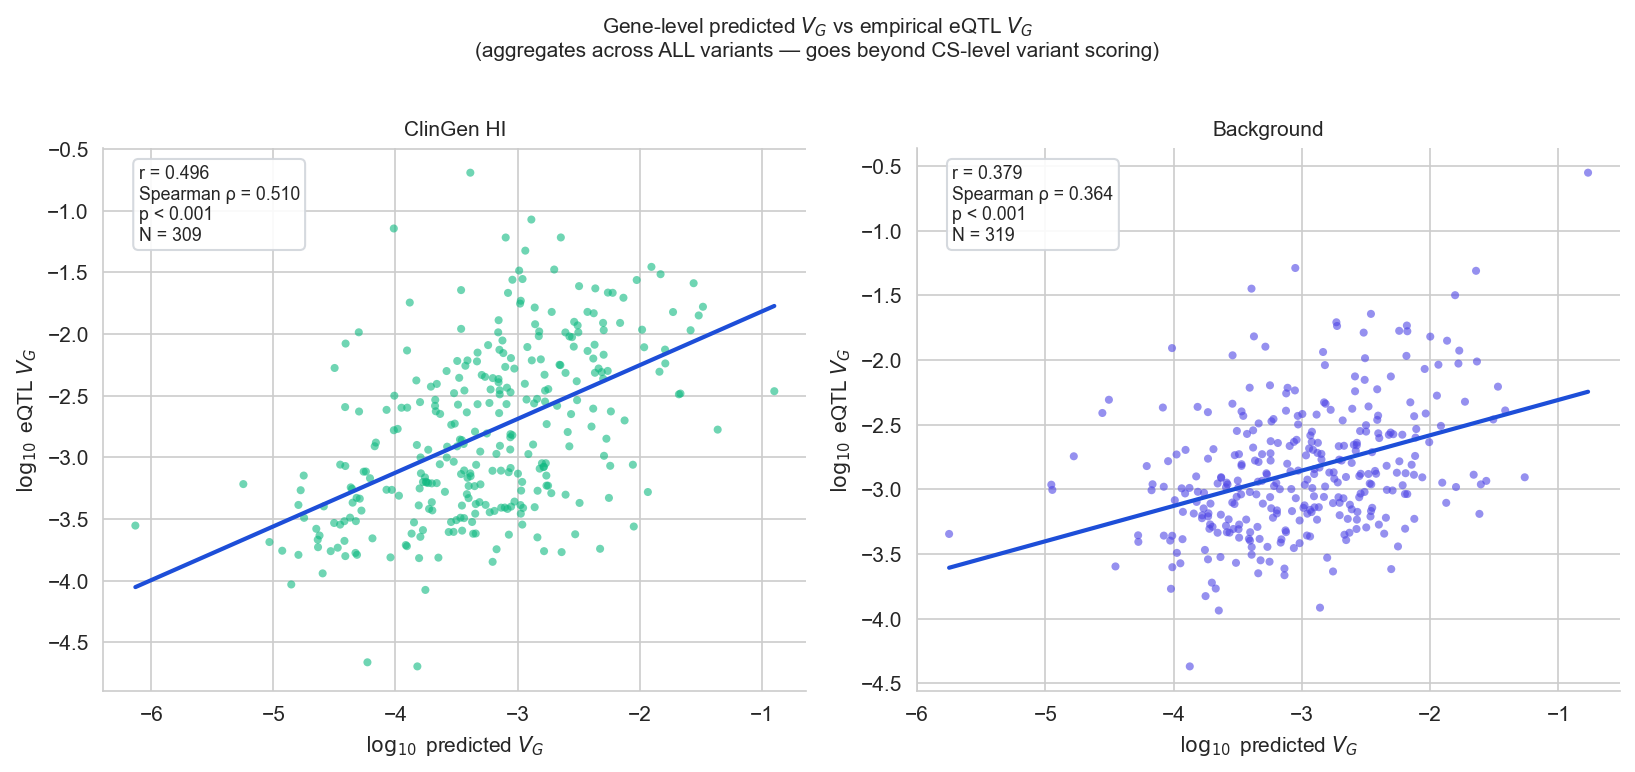

In [70]:
import polars as pl

df_hi_genes = pl.read_parquet(GENE_PATHS['clingen']).to_pandas()
df_bg_genes = pl.read_parquet(GENE_PATHS['background']).to_pandas()

for df, label in [(df_hi_genes, 'ClinGen HI'), (df_bg_genes, 'Background')]:
    if 'vg_eqtl' not in df.columns or 'vg_predicted' not in df.columns:
        print(f'{label}: missing vg_eqtl or vg_predicted column')
        continue
    sub = df[df['vg_eqtl'].notna() & (df['vg_eqtl'] > 0) & df['vg_predicted'].notna()].copy()
    r, p, ps = signed_rho(np.log10(sub['vg_predicted']), np.log10(sub['vg_eqtl']))
    rp, _ = pearsonr(np.log10(sub['vg_predicted']), np.log10(sub['vg_eqtl']))
    print(f'{label}: n={len(sub)}, r={rp:.3f}, ρ={r:.3f}, {ps}')

if 'vg_eqtl' in df_hi_genes.columns and 'vg_eqtl' in df_bg_genes.columns:
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for ax, (df, label, color) in zip(axes, [
        (df_hi_genes, 'ClinGen HI', COLOR_HI),
        (df_bg_genes, 'Background', COLOR_BG),
    ]):
        sub = df[df['vg_eqtl'].notna() & (df['vg_eqtl'] > 0) & df['vg_predicted'].notna()]
        x = np.log10(sub['vg_predicted'])
        y = np.log10(sub['vg_eqtl'])
        r, p, ps = signed_rho(x, y)
        rp, _ = pearsonr(x, y)
        ax.scatter(x, y, color=color, s=15, alpha=0.6, edgecolors='none', zorder=2)
        sl, ic, *_ = stats.linregress(x, y)
        xr = np.linspace(x.min(), x.max(), 200)
        ax.plot(xr, sl*xr+ic, color='#1D4ED8', lw=2.0, zorder=3)
        ax.set_xlabel(r'$log_{10}$ predicted $V_G$', fontsize=10)
        ax.set_ylabel(r'$log_{10}$ eQTL $V_G$', fontsize=10)
        ax.set_title(label, fontsize=10)
        ax.text(0.05, 0.97,
                f'r = {rp:.3f}\nSpearman ρ = {r:.3f}\n{ps}\nN = {len(sub):,}',
                transform=ax.transAxes, va='top', fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#D1D5DB', alpha=0.9))
        sns.despine(ax=ax)
    fig.suptitle(
        'Gene-level predicted $V_G$ vs empirical eQTL $V_G$\n'
        '(aggregates across ALL variants — goes beyond CS-level variant scoring)',
        fontsize=10, y=1.02
    )
    fig.tight_layout()
    save_plot(fig=fig, title='05_gene_level_vg_eqtl', notebook=NOTEBOOK_NAME, outdir=FIG_DIR)
    plt.show()
else:
    print('vg_eqtl not available in gene-level tables — skipping.')